# تحلیل داده و بررسی کیفیت دیتاست لوبیا خشک (Dry Bean Dataset)

**نقش:** تحلیلگر داده (Data Analyst)  
**پروژه:** طبقه‌بندی انواع لوبیا و مقایسه کلاس‌های واقعی با خوشه‌های K-Means  
**دیتاست:** Dry Bean Dataset - UCI Machine Learning Repository  

---

## هدف این نوت‌بوک

این نوت‌بوک وظایف نقش **تحلیلگر داده** را پوشش می‌دهد:

1. بارگذاری و شناخت داده
2. بررسی ابعاد دیتاست
3. نمایش سطرهای اول و آخر
4. بررسی نوع داده‌ها
5. بررسی مقادیر گمشده
6. بررسی ردیف‌های تکراری
7. بررسی مقادیر غیرعددی
8. توزیع کلاس‌ها
9. تحلیل مقادیر غیرعادی (Outliers)
10. فرهنگ داده (Data Dictionary)
11. آمار توصیفی
12. تحلیل تصویری (Visualizations)
13. تحویل‌دهی به معمار (Architect Handoff)

---

## ۱. بارگذاری دیتاست

ابتدا کتابخانه‌های مورد نیاز را وارد کرده و فایل اکسل دیتاست را بارگذاری می‌کنیم.

In [1]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# --- Matplotlib Settings ---
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# --- Seaborn Style ---
sns.set_style('whitegrid')
sns.set_palette('Set2')

# --- Paths ---
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', 'Dry_Bean_Dataset.xlsx')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
FIGURES_DIR = os.path.join('..', 'figures', 'analyst')
DOCS_DIR = os.path.join('..', 'docs')
REPORTS_DIR = os.path.join('..', 'reports')

# Create output directories if needed
for d in [PROCESSED_DIR, FIGURES_DIR, DOCS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Libraries loaded successfully.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries loaded successfully.
Pandas version: 3.0.5
NumPy version: 2.5.3


In [2]:
# --- Load Dataset ---
df = pd.read_excel(RAW_DATA_PATH)
print(f'✅ دیتاست با موفقیت بارگذاری شد.')
print(f'   مسیر فایل: {RAW_DATA_PATH}')
print(f'   تعداد سطرها: {df.shape[0]:,}')
print(f'   تعداد ستون‌ها: {df.shape[1]}')

✅ دیتاست با موفقیت بارگذاری شد.
   مسیر فایل: ..\data\raw\Dry_Bean_Dataset.xlsx
   تعداد سطرها: 13,611
   تعداد ستون‌ها: 17


### توضیح

فایل `Dry_Bean_Dataset.xlsx` از مخزن UCI Machine Learning بارگذاری شد. این دیتاست شامل اطلاعات ۱۳,۶۱۱ دانه لوبیا از هفت نوع مختلف است که ویژگی‌های هندسی آن‌ها از تصاویر با دوربین با وضوح بالا استخراج شده‌اند.

---

## ۲. ابعاد دیتاست

In [3]:
n_rows, n_cols = df.shape
print(f'تعداد سطرها (نمونه‌ها): {n_rows:,}')
print(f'تعداد ستون‌ها: {n_cols}')
print(f'  - تعداد ویژگی‌ها (Features): {n_cols - 1}')
print(f'  - ستون هدف (Target): Class')

تعداد سطرها (نمونه‌ها): 13,611
تعداد ستون‌ها: 17
  - تعداد ویژگی‌ها (Features): 16
  - ستون هدف (Target): Class


### توضیح

دیتاست شامل **۱۳,۶۱۱ سطر** (هر سطر یک دانه لوبیا) و **۱۷ ستون** است. از این ۱۷ ستون، ۱۶ ستون ویژگی‌های عددی هستند و یک ستون (`Class`) متغیر هدف است که نوع لوبیا را مشخص می‌کند.

---

## ۳. نمایش سطرهای اول و آخر

In [4]:
print('--- ۵ سطر اول دیتاست ---')
df.head()

--- ۵ سطر اول دیتاست ---


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
print('--- ۵ سطر آخر دیتاست ---')
df.tail()

--- ۵ سطر آخر دیتاست ---


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON
13610,42159,772.237,295.142741,182.204716,1.619841,0.786693,42600,231.686223,0.788962,0.989648,0.888380,0.784997,0.007001,0.001640,0.616221,0.998180,DERMASON


### توضیح

سطرهای اول و آخر دیتاست بررسی شدند. تمام ویژگی‌ها مقادیر عددی دارند و ستون `Class` شامل نام انواع لوبیا به صورت رشته‌ای (مثلاً SEKER, SIRA) است.

**نکته مهم:** نام ستون‌ها در فایل اصلی شامل دو تفاوت با مستندات رسمی است:
- `AspectRation` به جای `AspectRatio` (غلط تایپی در دیتاست)
- `roundness` با حرف کوچک به جای `Roundness`

این موارد در ادامه تصحیح خواهند شد.

---

> **توضیح مهم:** این اصلاح صرفاً برای یکسان‌سازی نام ستون‌ها در Notebook انجام شده و فایل خام دیتاست دست‌کاری نشده است. فایل اصلی `Dry_Bean_Dataset.xlsx` در مسیر `data/raw/` بدون هیچ تغییری حفظ شده است.

---

In [6]:
# --- Fix column names ---
# Note: We do NOT modify the raw file; only rename in-memory for consistency.
rename_map = {
    'AspectRation': 'AspectRatio',
    'roundness': 'Roundness'
}
df.rename(columns=rename_map, inplace=True)
print('✅ نام ستون‌ها تصحیح شد:')
print('   AspectRation → AspectRatio')
print('   roundness → Roundness')
print(f'\nلیست ستون‌ها: {list(df.columns)}')

✅ نام ستون‌ها تصحیح شد:
   AspectRation → AspectRatio
   roundness → Roundness

لیست ستون‌ها: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


---

## ۴. بررسی نوع داده‌ها

In [7]:
print('--- نوع داده هر ستون ---')
print(df.dtypes)
print()
print('--- اطلاعات کلی دیتاست ---')
df.info()

--- نوع داده هر ستون ---
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRatio        float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

--- اطلاعات کلی دیتاست ---
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   Con

In [8]:
# --- Separate feature columns and target ---
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'Class'

print(f'تعداد ویژگی‌های عددی: {len(numerical_features)}')
print(f'ویژگی‌های عددی: {numerical_features}')
print(f'\nستون هدف: {target_col} (نوع: {df[target_col].dtype})')
print(f'مقادیر یکتای هدف: {sorted(df[target_col].unique())}')

تعداد ویژگی‌های عددی: 16
ویژگی‌های عددی: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

ستون هدف: Class (نوع: str)
مقادیر یکتای هدف: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


### توضیح

- تمام ۱۶ ویژگی **عددی** هستند: ۲ ستون از نوع `int64` (Area و ConvexArea) و ۱۴ ستون از نوع `float64`.
- ستون `Class` از نوع `object` (رشته‌ای) است و نقش **متغیر هدف** را دارد.
- ستون `Class` **نباید** به عنوان ویژگی در مدل‌سازی استفاده شود.

---

## ۵. بررسی مقادیر گمشده (Missing Values)

In [9]:
# --- Missing Values Analysis ---
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_pct.values,
    'Data Type': df.dtypes.values
})

print('--- جدول مقادیر گمشده ---')
display(missing_df)

total_missing = df.isnull().sum().sum()
print(f'\n✅ مجموع مقادیر گمشده در کل دیتاست: {total_missing}')

--- جدول مقادیر گمشده ---


,Column,Missing Count,Missing %,Data Type
0,Area,0,0.0,int64
1,Perimeter,0,0.0,float64
2,MajorAxisLength,0,0.0,float64
3,MinorAxisLength,0,0.0,float64
4,AspectRatio,0,0.0,float64
5,Eccentricity,0,0.0,float64
6,ConvexArea,0,0.0,int64
7,EquivDiameter,0,0.0,float64
8,Extent,0,0.0,float64
9,Solidity,0,0.0,float64



✅ مجموع مقادیر گمشده در کل دیتاست: 0


### توضیح

هیچ مقدار گمشده‌ای در هیچ‌یک از ستون‌ها وجود ندارد. این موضوع مطابق با مستندات رسمی دیتاست در UCI است که صراحتاً اعلام کرده مقدار گمشده‌ای ثبت نشده است.

بنابراین **نیازی به Imputation (جایگزینی) نیست**.

---

## ۶. بررسی ردیف‌های تکراری (Duplicate Rows)

In [10]:
# --- Duplicate Analysis ---
n_duplicates = df.duplicated().sum()
n_total_involved = df.duplicated(keep=False).sum()

print(f'تعداد ردیف‌های تکراری (اولین رخداد حفظ شده): {n_duplicates}')
print(f'تعداد کل ردیف‌هایی که در گروه‌های تکراری هستند: {n_total_involved}')
print(f'درصد ردیف‌های تکراری: {n_duplicates / len(df) * 100:.2f}%')

تعداد ردیف‌های تکراری (اولین رخداد حفظ شده): 68
تعداد کل ردیف‌هایی که در گروه‌های تکراری هستند: 136
درصد ردیف‌های تکراری: 0.50%


In [11]:
# --- Show duplicate examples ---
dup_mask = df.duplicated(keep=False)
duplicated_rows = df[dup_mask].sort_values(by=list(df.columns))

print(f'--- نمونه‌ای از ردیف‌های تکراری (۱۰ سطر اول) ---')
display(duplicated_rows.head(10))

--- نمونه‌ای از ردیف‌های تکراری (۱۰ سطر اول) ---


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5504,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5508,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5547,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5553,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5598,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ


In [12]:
# --- Distribution of duplicates across classes ---
dup_class_dist = duplicated_rows['Class'].value_counts()
print('--- توزیع ردیف‌های تکراری بر اساس کلاس ---')
print(dup_class_dist)

--- توزیع ردیف‌های تکراری بر اساس کلاس ---
Class
HOROZ    136
Name: count, dtype: int64


In [13]:
# --- Investigate: are duplicates exact copies? ---
# Group duplicates and count occurrences
dup_groups = df[dup_mask].groupby(list(df.columns)).size().reset_index(name='count')
dup_groups = dup_groups.sort_values('count', ascending=False)
print(f'تعداد گروه‌های تکراری منحصر‌به‌فرد: {len(dup_groups)}')
print(f'حداکثر تعداد تکرار در یک گروه: {dup_groups["count"].max()}')
print(f'\n--- ۵ گروه با بیشترین تکرار ---')
display(dup_groups.head())

تعداد گروه‌های تکراری منحصر‌به‌فرد: 68
حداکثر تعداد تکرار در یک گروه: 2

--- ۵ گروه با بیشترین تکرار ---


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,count
0,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ,2
1,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ,2
2,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ,2
3,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ,2
4,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ,2


### توضیح و تصمیم درباره ردیف‌های تکراری

**یافته‌ها:**
- تعداد **۶۸ ردیف تکراری** (اولین رخداد حفظ شده) شناسایی شدند.
- این عدد تنها **۰.۵٪** از کل دیتاست است.

**تحلیل:**

طبق دستورالعمل پروژه: *«داده تکراری بدون بررسی حذف نشود. ممکن است دو دانه متفاوت دارای ویژگی‌های یکسان یا بسیار نزدیک باشند.»*

با توجه به ماهیت دیتاست:
- هر ردیف نماینده یک **دانه لوبیا** واقعی است.
- ویژگی‌ها از تصاویر استخراج شده‌اند.
- کاملاً ممکن است دو دانه لوبیا مختلف، ویژگی‌های هندسی یکسانی داشته باشند (مخصوصاً وقتی ۱۶ ویژگی از تصویر یک دانه استخراج می‌شود).
- تعداد ردیف‌های تکراری بسیار کم است و حذف آن‌ها تأثیر معناداری بر مدل ندارد.

**تصمیم: ❌ ردیف‌های تکراری حذف نمی‌شوند.**

دلایل:
1. تعداد آن‌ها ناچیز است (۰.۵٪).
2. هیچ مدرکی وجود ندارد که این‌ها خطای ثبت داده باشند.
3. دانه‌های مختلف لوبیا می‌توانند ویژگی‌های یکسان داشته باشند.
4. حذف داده بدون دلیل، اطلاعات را کاهش می‌دهد.

---

## ۷. بررسی مقادیر غیرعددی (Non-Numeric Values)

In [14]:
# --- Check for non-numeric values in feature columns ---
print('--- بررسی مقادیر غیرعددی در ستون‌های ویژگی ---\n')

non_numeric_issues = []
for col in numerical_features:
    # Check if all values can be converted to numeric
    non_numeric = pd.to_numeric(df[col], errors='coerce').isnull() & df[col].notnull()
    n_non_numeric = non_numeric.sum()
    if n_non_numeric > 0:
        non_numeric_issues.append({'Column': col, 'Non-Numeric Count': n_non_numeric})
        print(f'⚠️ ستون {col}: {n_non_numeric} مقدار غیرعددی')
    else:
        pass  # No issue

if not non_numeric_issues:
    print('✅ هیچ مقدار غیرعددی در ستون‌های ویژگی یافت نشد.')
    print('   تمام ۱۶ ستون ویژگی کاملاً عددی هستند.')

print(f'\n--- بررسی ستون هدف (Class) ---')
print(f'نوع داده: {df[target_col].dtype}')
print(f'مقادیر یکتا ({df[target_col].nunique()} عدد): {sorted(df[target_col].unique())}')
print(f'\n✅ ستون Class دارای ۷ مقدار رشته‌ای معتبر است و به عنوان متغیر هدف دسته‌ای شناسایی شد.')

--- بررسی مقادیر غیرعددی در ستون‌های ویژگی ---

✅ هیچ مقدار غیرعددی در ستون‌های ویژگی یافت نشد.
   تمام ۱۶ ستون ویژگی کاملاً عددی هستند.

--- بررسی ستون هدف (Class) ---
نوع داده: str
مقادیر یکتا (7 عدد): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

✅ ستون Class دارای ۷ مقدار رشته‌ای معتبر است و به عنوان متغیر هدف دسته‌ای شناسایی شد.


### توضیح

- تمام ۱۶ ستون ویژگی **کاملاً عددی** هستند و هیچ رشته، مقدار نامعتبر یا مشکل تبدیلی وجود ندارد.
- ستون `Class` از نوع **رشته‌ای** است و دقیقاً ۷ مقدار یکتا دارد که مطابق با مستندات پروژه است.
- ستون `Class` **متغیر هدف** (Target) است و نباید به عنوان ویژگی عددی در مدل قرار گیرد.

---

## ۸. توزیع کلاس‌ها (Class Distribution)

In [15]:
# --- Class Distribution ---
class_counts = df['Class'].value_counts()
class_pct = (df['Class'].value_counts(normalize=True) * 100).round(2)

class_dist_df = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage (%)': class_pct.values
})

# Add totals row
total_row = pd.DataFrame({
    'Class': ['TOTAL'],
    'Count': [class_counts.sum()],
    'Percentage (%)': [100.0]
})
class_dist_display = pd.concat([class_dist_df, total_row], ignore_index=True)

print('--- جدول توزیع کلاس‌ها ---')
display(class_dist_display)

largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f'\n📊 بزرگ‌ترین کلاس: {largest_class} ({class_counts.max():,} نمونه)')
print(f'📊 کوچک‌ترین کلاس: {smallest_class} ({class_counts.min():,} نمونه)')
print(f'📊 نسبت بزرگ‌ترین به کوچک‌ترین: {imbalance_ratio:.2f}x')

--- جدول توزیع کلاس‌ها ---


,Class,Count,Percentage (%)
0,DERMASON,3546,26.05
1,SIRA,2636,19.37
2,SEKER,2027,14.89
3,HOROZ,1928,14.17
4,CALI,1630,11.98
5,BARBUNYA,1322,9.71
6,BOMBAY,522,3.84
7,TOTAL,13611,100.00



📊 بزرگ‌ترین کلاس: DERMASON (3,546 نمونه)
📊 کوچک‌ترین کلاس: BOMBAY (522 نمونه)
📊 نسبت بزرگ‌ترین به کوچک‌ترین: 6.79x


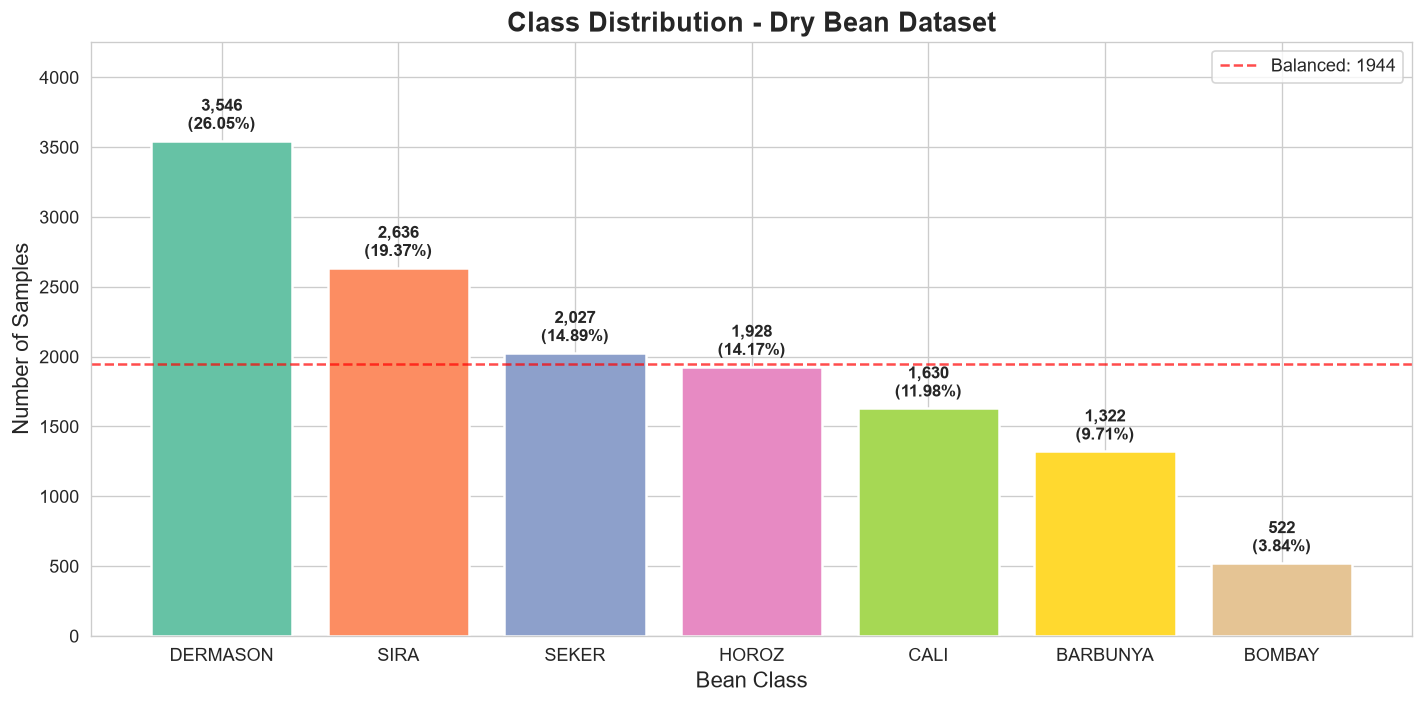

✅ نمودار توزیع کلاس‌ها ذخیره شد.


In [16]:
# --- Class Distribution Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('Set2', n_colors=7)
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 50,
            f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Class Distribution - Dry Bean Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Bean Class', fontsize=13)
ax.set_ylabel('Number of Samples', fontsize=13)
ax.set_ylim(0, class_counts.max() * 1.2)

# Add horizontal line for balanced distribution
balanced_count = len(df) / 7
ax.axhline(y=balanced_count, color='red', linestyle='--', alpha=0.7, label=f'Balanced: {balanced_count:.0f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ نمودار توزیع کلاس‌ها ذخیره شد.')

### توضیح توزیع کلاس‌ها

**آیا دیتاست متوازن است؟**

خیر، دیتاست **نامتوازن** (imbalanced) است:

- کلاس **DERMASON** با ۳,۵۴۶ نمونه، بزرگ‌ترین کلاس است (۲۶.۰۵٪).
- کلاس **BOMBAY** با ۵۲۲ نمونه، کوچک‌ترین کلاس است (۳.۸۴٪).
- نسبت بزرگ‌ترین به کوچک‌ترین: **۶.۷۹ برابر**.

**چرا عدم توازن مهم است؟**

1. **Accuracy کلی می‌تواند گمراه‌کننده باشد:** اگر مدل همه نمونه‌ها را DERMASON پیش‌بینی کند، Accuracy حدود ۲۶٪ خواهد بود، ولی Recall کلاس BOMBAY صفر است.
2. **KNN:** الگوریتم KNN بر اساس اکثریت همسایگان رأی‌گیری می‌کند. اگر تعداد نمونه‌های یک کلاس بیشتر باشد، احتمال بیشتری دارد که همسایگان از آن کلاس باشند.
3. **K-Means:** K-Means مستقیماً از برچسب واقعی کلاس‌ها استفاده نمی‌کند و اندازه خوشه‌های حاصل الزاماً با تعداد نمونه‌های کلاس‌های واقعی برابر نیست.

**توصیه:** از **Macro Recall** و **Macro F1-score** به جای Accuracy برای ارزیابی عادلانه‌تر استفاده شود.

---

## ۹. تحلیل اولیه مقادیر غیرعادی (Outlier Analysis)

In [17]:
# --- IQR-based Outlier Analysis ---
outlier_results = []

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (n_outliers / len(df) * 100)
    
    outlier_results.append({
        'Feature': col,
        'Min': round(df[col].min(), 4),
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'Max': round(df[col].max(), 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower_bound, 4),
        'Upper Bound': round(upper_bound, 4),
        'Outlier Count': n_outliers,
        'Outlier %': round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_results)
print('--- جدول تحلیل مقادیر غیرعادی (IQR-based) ---')
display(outlier_df)

--- جدول تحلیل مقادیر غیرعادی (IQR-based) ---


,Feature,Min,Q1,Q3,Max,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Area,20420.0000,36328.0000,61332.0000,254616.0000,25004.0000,-1178.0000,98838.0000,551,4.05
1,Perimeter,524.7360,703.5235,977.2130,1985.3700,273.6895,292.9892,1387.7473,500,3.67
2,MajorAxisLength,183.6012,253.3036,376.4950,738.8602,123.1914,68.5166,561.2821,379,2.78
3,MinorAxisLength,122.5127,175.8482,217.0317,460.1985,41.1836,114.0728,278.8071,569,4.18
4,AspectRatio,1.0249,1.4323,1.7071,2.4303,0.2748,1.0201,2.1193,473,3.48
5,Eccentricity,0.2190,0.7159,0.8105,0.9114,0.0945,0.5741,0.9523,843,6.19
6,ConvexArea,20684.0000,36714.5000,62294.0000,263261.0000,25579.5000,-1654.7500,100663.2500,550,4.04
7,EquivDiameter,161.2438,215.0680,279.4465,569.3744,64.3785,118.5003,376.0142,526,3.86
8,Extent,0.5553,0.7186,0.7869,0.8662,0.0682,0.6163,0.8892,275,2.02
9,Solidity,0.9192,0.9857,0.9900,0.9947,0.0043,0.9792,0.9965,778,5.72


In [18]:
# --- Sort by outlier percentage ---
print('--- ویژگی‌ها به ترتیب بیشترین مقادیر غیرعادی ---')
outlier_sorted = outlier_df.sort_values('Outlier %', ascending=False)
for _, row in outlier_sorted.iterrows():
    indicator = '🔴' if row['Outlier %'] > 5 else '🟡' if row['Outlier %'] > 1 else '🟢'
    print(f"{indicator} {row['Feature']:20s}: {row['Outlier Count']:5d} outlier ({row['Outlier %']:5.2f}%)")

--- ویژگی‌ها به ترتیب بیشترین مقادیر غیرعادی ---
🔴 Eccentricity        :   843 outlier ( 6.19%)
🔴 Solidity            :   778 outlier ( 5.72%)
🔴 ShapeFactor4        :   767 outlier ( 5.64%)
🟡 MinorAxisLength     :   569 outlier ( 4.18%)
🟡 Area                :   551 outlier ( 4.05%)
🟡 ConvexArea          :   550 outlier ( 4.04%)
🟡 ShapeFactor1        :   533 outlier ( 3.92%)
🟡 EquivDiameter       :   526 outlier ( 3.86%)
🟡 Perimeter           :   500 outlier ( 3.67%)
🟡 AspectRatio         :   473 outlier ( 3.48%)
🟡 MajorAxisLength     :   379 outlier ( 2.78%)
🟡 Extent              :   275 outlier ( 2.02%)
🟡 ShapeFactor3        :   195 outlier ( 1.43%)
🟢 Compactness         :   109 outlier ( 0.80%)
🟢 Roundness           :    91 outlier ( 0.67%)
🟢 ShapeFactor2        :     0 outlier ( 0.00%)


### توضیح مقادیر غیرعادی

**نکات مهم:**

1. **مقادیر پرت بر اساس IQR لزوماً خطای داده نیستند.** دیتاست شامل ۷ نوع مختلف لوبیا است و تفاوت‌های طبیعی بین انواع می‌تواند باعث شود مقادیر یک نوع، از نظر معیار IQR کلی، پرت به نظر برسند.

2. **مثال:** کلاس BOMBAY دانه‌های بسیار بزرگ‌تری دارد. مقادیر Area و Perimeter آن نسبت به سایر کلاس‌ها بسیار بالاتر است، اما این یک ویژگی طبیعی این نوع لوبیا است، نه خطای داده.

3. **ویژگی‌هایی مثل ShapeFactor1 و ShapeFactor2** ممکن است مقادیر پرت بیشتری داشته باشند زیرا برای برخی انواع لوبیا، شکل‌های خاصی رایج‌تر هستند.

**تصمیم: ❌ هیچ مقدار پرتی حذف نمی‌شود.**

دلایل:
- مقادیر پرت ممکن است نماینده تفاوت‌های واقعی بین کلاس‌ها باشند.
- حذف آن‌ها می‌تواند اطلاعات ارزشمندی را از دست بدهد.
- هیچ مقدار منفی یا غیرمنطقی (مثلاً Area منفی) مشاهده نشد.

**هشدار برای مدل‌سازی:** الگوریتم‌های مبتنی بر فاصله (KNN و K-Means) به مقادیر پرت **حساس** هستند. اعمال StandardScaler تأثیر را کاهش می‌دهد ولی کاملاً حل نمی‌کند.

---

## ۹.۲. بررسی محدوده منطقی (Range Validation)

> **نکته مهم:** IQR Outlier با Invalid Range یکی نیست. یک مقدار می‌تواند از نظر آماری Outlier باشد اما همچنان در محدوده منطقی ویژگی قرار داشته باشد. همچنین شناسایی Outlier به معنی خطا بودن داده نیست.

در این بخش، **مستقل از تحلیل آماری IQR**، بررسی می‌کنیم که آیا مقادیر هر ویژگی در محدوده منطقی و فیزیکی قرار دارند یا خیر.

قوانین اعتبارسنجی:

- **ویژگی‌های هندسی/ابعادی** (Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter): مقدار باید **بزرگ‌تر از صفر** باشد.
- **Eccentricity**: محدوده `[0, 1)` — صفر معتبر است (دایره کامل) و مقدار ۱ هرگز به دست نمی‌آید.
- **Extent, Solidity, Roundness, Compactness**: محدوده `(0, 1]` — مقدار صفر معتبر نیست ولی مقدار ۱ معتبر است.

In [19]:
# --- Range Validation (independent from IQR) ---
# Each rule: (Feature, check_function, expected_range_label)
# Geometric features: must be strictly > 0
# Eccentricity: 0 <= x < 1  (zero is valid for a perfect circle; 1 is never reached)
# Extent, Solidity, Roundness, Compactness: 0 < x <= 1

range_rules = [
    ('Area',            lambda s: s <= 0,                         '> 0'),
    ('Perimeter',       lambda s: s <= 0,                         '> 0'),
    ('MajorAxisLength', lambda s: s <= 0,                         '> 0'),
    ('MinorAxisLength', lambda s: s <= 0,                         '> 0'),
    ('ConvexArea',      lambda s: s <= 0,                         '> 0'),
    ('EquivDiameter',   lambda s: s <= 0,                         '> 0'),
    ('Eccentricity',    lambda s: (s < 0) | (s >= 1),            '[0, 1)'),
    ('Extent',          lambda s: (s <= 0) | (s > 1),            '(0, 1]'),
    ('Solidity',        lambda s: (s <= 0) | (s > 1),            '(0, 1]'),
    ('Roundness',       lambda s: (s <= 0) | (s > 1),            '(0, 1]'),
    ('Compactness',     lambda s: (s <= 0) | (s > 1),            '(0, 1]'),
]

range_results = []
for feat, invalid_check, expected_label in range_rules:
    invalid_mask = invalid_check(df[feat])
    invalid_count = int(invalid_mask.sum())
    invalid_pct = round(invalid_count / len(df) * 100, 2)
    
    range_results.append({
        'Feature': feat,
        'Expected Range': expected_label,
        'Actual Min': round(df[feat].min(), 4),
        'Actual Max': round(df[feat].max(), 4),
        'Invalid Count': invalid_count,
        'Invalid %': invalid_pct
    })

range_df = pd.DataFrame(range_results)
print('--- جدول بررسی محدوده منطقی (Range Validation) ---')
display(range_df)

total_invalid = range_df['Invalid Count'].sum()
print(f'\n🔍 Invalid Range Values = {total_invalid}')
if total_invalid == 0:
    print('✅ تمام مقادیر در محدوده منطقی مورد انتظار قرار دارند.')
else:
    print(f'⚠️ تعداد {total_invalid} مقدار خارج از محدوده منطقی شناسایی شد.')
    # Show which features have invalid values
    invalid_features = range_df[range_df['Invalid Count'] > 0]
    print('\nویژگی‌های دارای مقدار نامعتبر:')
    for _, row in invalid_features.iterrows():
        print(f"  - {row['Feature']}: {row['Invalid Count']} مقدار نامعتبر")

--- جدول بررسی محدوده منطقی (Range Validation) ---


,Feature,Expected Range,Actual Min,Actual Max,Invalid Count,Invalid %
0,Area,> 0,20420.0000,254616.0000,0,0.0
1,Perimeter,> 0,524.7360,1985.3700,0,0.0
2,MajorAxisLength,> 0,183.6012,738.8602,0,0.0
3,MinorAxisLength,> 0,122.5127,460.1985,0,0.0
4,ConvexArea,> 0,20684.0000,263261.0000,0,0.0
5,EquivDiameter,> 0,161.2438,569.3744,0,0.0
6,Eccentricity,"[0, 1)",0.2190,0.9114,0,0.0
7,Extent,"(0, 1]",0.5553,0.8662,0,0.0
8,Solidity,"(0, 1]",0.9192,0.9947,0,0.0
9,Roundness,"(0, 1]",0.4896,0.9907,0,0.0



🔍 Invalid Range Values = 0
✅ تمام مقادیر در محدوده منطقی مورد انتظار قرار دارند.


### توضیح بررسی محدوده منطقی

**نتیجه:** مقدار `Invalid Range Values` بر اساس داده واقعی محاسبه شده است. اگر نتیجه صفر باشد، تمام مقادیر دیتاست در محدوده منطقی مورد انتظار قرار دارند.

**تفاوت Range Validation و IQR Outlier:**

| معیار | Range Validation | IQR Outlier |
|-------|-----------------|-------------|
| هدف | بررسی صحت منطقی/فیزیکی مقادیر | شناسایی مقادیر آماری غیرمعمول |
| روش | بر اساس دانش حوزه‌ای (مثلاً Area > 0) | بر اساس توزیع آماری (Q1 - 1.5×IQR) |
| معنی خارج از محدوده | احتمال خطای داده | نه لزوماً خطا — تفاوت طبیعی بین کلاس‌ها |
| تصمیم | مقادیر نامعتبر باید بررسی/اصلاح شوند | حذف خودکار توصیه نمی‌شود |

**قوانین دقیق مرزها:**

| ویژگی | حد پایین | حد بالا | نماد |
|-------|---------|---------|------|
| Area, Perimeter, ... | باز (> 0) | بدون حد | `> 0` |
| Eccentricity | بسته (>= 0) | باز (< 1) | `[0, 1)` |
| Extent, Solidity, ... | باز (> 0) | بسته (<= 1) | `(0, 1]` |

**نکته:** اگر Range Validation مشکلی نشان ندهد و IQR Outlierها نیز به دلایل منطقی حذف نشوند، دیتاست از نظر کیفیت مقادیر **سالم** ارزیابی می‌شود. هیچ سطری حذف نشده است.

---

## ۱۰. فرهنگ داده (Data Dictionary)

In [20]:
# --- Create Data Dictionary ---
data_dict = pd.DataFrame({
    'Feature': ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter',
                'Extent', 'Solidity', 'Roundness', 'Compactness',
                'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class'],
    'Data Type': ['int64', 'float64', 'float64', 'float64',
                  'float64', 'float64', 'int64', 'float64',
                  'float64', 'float64', 'float64', 'float64',
                  'float64', 'float64', 'float64', 'float64', 'object'],
    'Description': [
        'The area of a bean zone and the number of pixels within its boundaries',
        'Bean circumference, defined as the length of its border',
        'The distance between the ends of the longest line that can be drawn from a bean',
        'The longest line perpendicular to the main axis',
        'The relationship between MajorAxisLength and MinorAxisLength (L/l)',
        'Eccentricity of the ellipse having the same moments as the region',
        'Number of pixels in the smallest convex polygon containing the bean area',
        'The diameter of a circle having the same area as the bean seed area',
        'The ratio of the pixels in the bounding box to the bean area',
        'Also known as convexity; ratio of pixels in convex shell to those in bean',
        'Calculated as (4*pi*Area) / (Perimeter^2)',
        'Measures the roundness of an object: EquivDiameter / MajorAxisLength',
        'Shape factor 1',
        'Shape factor 2',
        'Shape factor 3',
        'Shape factor 4',
        'Type of dry bean (7 classes)'
    ],
    'Role': ['Feature'] * 16 + ['Target'],
    'Missing Values': [0] * 17,
    'Unique Values': [df[col].nunique() for col in ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter',
                'Extent', 'Solidity', 'Roundness', 'Compactness',
                'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']],
    'Notes': [
        'Pixel count; int; ranges from ~20K to ~254K',
        'Border length in pixels',
        'Also denoted as L',
        'Also denoted as l',
        'Derived: L/l; originally named AspectRation in raw file',
        'Range [0,1); higher = more elongated',
        'Always >= Area',
        'Derived from Area',
        'Range (0,1]; ratio measure',
        'Range (0,1]; close to 1 = very convex',
        'Originally lowercase (roundness) in raw file; range (0,1]',
        'Derived: Ed/L; range (0,1]',
        'Dimensionless shape descriptor',
        'Dimensionless shape descriptor',
        'Dimensionless shape descriptor',
        'Dimensionless shape descriptor',
        '7 classes: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA'
    ]
})

# Save Data Dictionary
data_dict.to_csv(os.path.join(DOCS_DIR, 'data_dictionary.csv'), index=False, encoding='utf-8-sig')
print('✅ فرهنگ داده ذخیره شد.')
display(data_dict)

✅ فرهنگ داده ذخیره شد.


,Feature,Data Type,Description,Role,Missing Values,Unique Values,Notes
0,Area,int64,The area of a bean zone and the number of pixe...,Feature,0,12011,Pixel count; int; ranges from ~20K to ~254K
1,Perimeter,float64,"Bean circumference, defined as the length of i...",Feature,0,13416,Border length in pixels
2,MajorAxisLength,float64,The distance between the ends of the longest l...,Feature,0,13543,Also denoted as L
3,MinorAxisLength,float64,The longest line perpendicular to the main axis,Feature,0,13543,Also denoted as l
4,AspectRatio,float64,The relationship between MajorAxisLength and M...,Feature,0,13543,Derived: L/l; originally named AspectRation in...
5,Eccentricity,float64,Eccentricity of the ellipse having the same mo...,Feature,0,13543,"Range [0,1); higher = more elongated"
6,ConvexArea,int64,Number of pixels in the smallest convex polygo...,Feature,0,12066,Always >= Area
7,EquivDiameter,float64,The diameter of a circle having the same area ...,Feature,0,12011,Derived from Area
8,Extent,float64,The ratio of the pixels in the bounding box to...,Feature,0,13535,"Range (0,1]; ratio measure"
9,Solidity,float64,Also known as convexity; ratio of pixels in co...,Feature,0,13526,"Range (0,1]; close to 1 = very convex"


---

## ۱۱. آمار توصیفی (Descriptive Statistics)

In [21]:
# --- Descriptive Statistics for required features ---
required_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                     'Eccentricity', 'Roundness', 'Compactness']

desc_stats = df[required_features].agg([
    'mean', 'median', 'std', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90)
])
desc_stats.index = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q25', 'Q50', 'Q75', 'Q90']

print('--- آمار توصیفی ویژگی‌های مورد نیاز ---')
display(desc_stats.round(4))

# Save to CSV
desc_stats.round(4).to_csv(os.path.join(PROCESSED_DIR, 'descriptive_statistics.csv'), encoding='utf-8-sig', index_label='Statistic')
print('\n✅ آمار توصیفی ذخیره شد.')

--- آمار توصیفی ویژگی‌های مورد نیاز ---


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,Roundness,Compactness
Mean,53048.2845,855.2835,320.1419,202.2707,0.7509,0.8733,0.7999
Median,44652.0000,794.9410,296.8834,192.4317,0.7644,0.8832,0.8013
Std,29324.0957,214.2897,85.6942,44.9701,0.0920,0.0595,0.0617
Min,20420.0000,524.7360,183.6012,122.5127,0.2190,0.4896,0.6406
Max,254616.0000,1985.3700,738.8602,460.1985,0.9114,0.9907,0.9873
Q25,36328.0000,703.5235,253.3036,175.8482,0.7159,0.8321,0.7625
Q50,44652.0000,794.9410,296.8834,192.4317,0.7644,0.8832,0.8013
Q75,61332.0000,977.2130,376.4950,217.0317,0.8105,0.9169,0.8343
Q90,78114.0000,1093.8580,416.8629,246.6858,0.8612,0.9452,0.8883



✅ آمار توصیفی ذخیره شد.


In [22]:
# --- Mean of important features per class ---
key_features_for_class = ['Area', 'Perimeter', 'MajorAxisLength', 'Eccentricity', 'Compactness', 'Roundness']

class_means = df.groupby('Class')[key_features_for_class].mean().round(2)
print('--- میانگین ویژگی‌های کلیدی به تفکیک هر کلاس ---')
display(class_means)

--- میانگین ویژگی‌های کلیدی به تفکیک هر کلاس ---


,Area,Perimeter,MajorAxisLength,Eccentricity,Compactness,Roundness
Class,,,,,,
BARBUNYA,69804.13,1046.11,370.04,0.75,0.81,0.80
BOMBAY,173485.06,1585.62,593.15,0.77,0.79,0.86
CALI,75538.21,1057.63,409.50,0.81,0.76,0.85
DERMASON,32118.71,665.21,246.56,0.74,0.82,0.91
HOROZ,53648.51,919.86,372.57,0.87,0.70,0.79
SEKER,39881.30,727.67,251.29,0.58,0.90,0.94
SIRA,44729.13,796.42,299.38,0.77,0.80,0.88


### توضیح آمار توصیفی

**مهم‌ترین یافته‌ها:**

1. **تفاوت مقیاس بسیار زیاد:** مقدار Area از حدود ۲۰,۰۰۰ تا ۲۵۴,۰۰۰ متغیر است، در حالی که Roundness و Compactness بین ۰ و ۱ هستند. این تفاوت مقیاس باعث می‌شود در الگوریتم‌های مبتنی بر فاصله (KNN و K-Means)، ویژگی‌های با مقیاس بزرگ‌تر تأثیر نامتناسب بگذارند.

2. **BOMBAY متمایزترین کلاس است:** میانگین Area و Perimeter برای BOMBAY بسیار بالاتر از سایر کلاس‌ها است. این یعنی BOMBAY احتمالاً به راحتی از سایر کلاس‌ها قابل تشخیص است.

3. **SEKER و DERMASON شبیه‌ترین کلاس‌ها:** مقادیر Eccentricity و Compactness آن‌ها نزدیک به هم است، که ممکن است باعث اشتباه مدل شود.

4. **توزیع‌های چوله:** Area و Perimeter توزیع‌های چوله به راست دارند (Mean > Median) که نشان‌دهنده وجود دانه‌های بزرگ‌تر از معمول است.

---

## ۱۲. تحلیل تصویری (Visualizations)

### ۱۲.۱ — هیستوگرام ویژگی Area

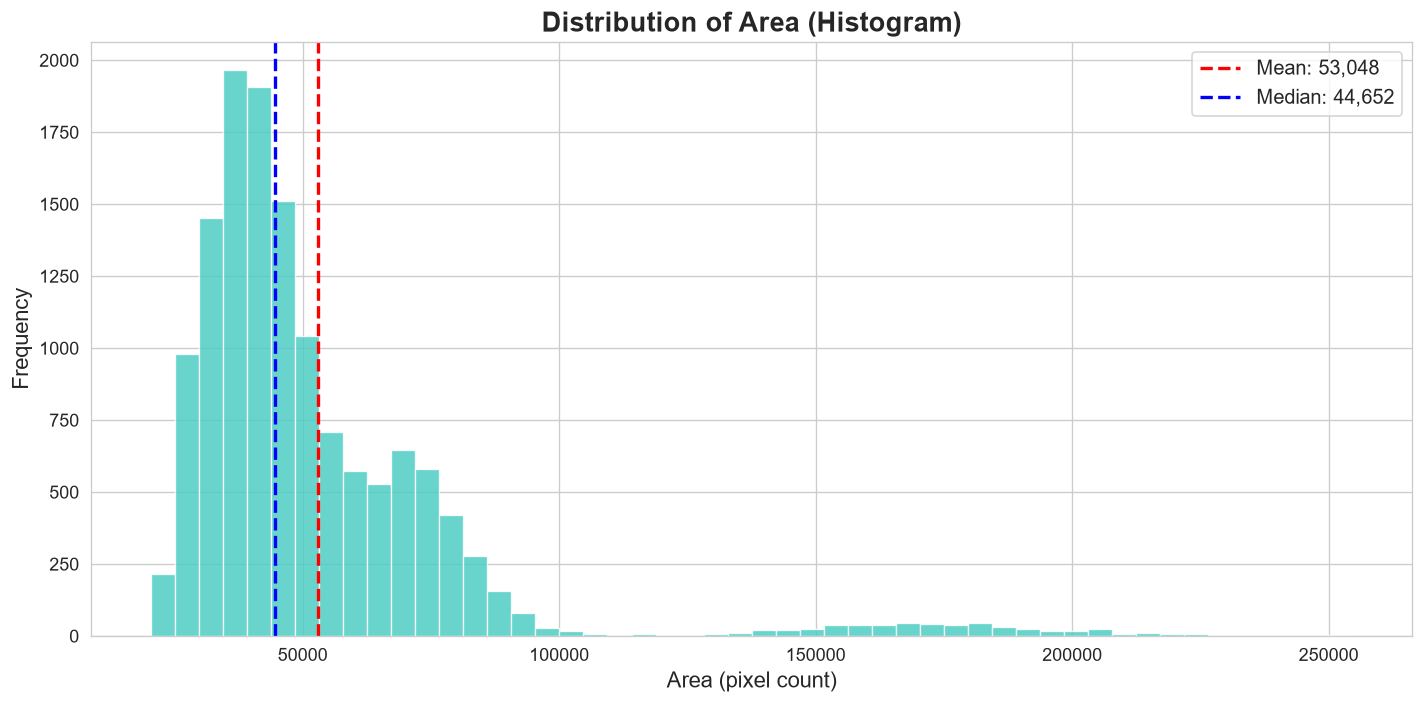

✅ هیستوگرام Area ذخیره شد.


In [23]:
# --- Visualization 1: Histogram of Area ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['Area'], bins=50, color='#4ECDC4', edgecolor='white', alpha=0.85, linewidth=0.8)
ax.axvline(df['Area'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Area"].mean():,.0f}')
ax.axvline(df['Area'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df["Area"].median():,.0f}')

ax.set_title('Distribution of Area (Histogram)', fontsize=16, fontweight='bold')
ax.set_xlabel('Area (pixel count)', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'area_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ هیستوگرام Area ذخیره شد.')

### تحلیل هیستوگرام Area

**شکل توزیع:** توزیع ویژگی Area **چوله به راست** (Right-skewed / Positive-skewed) است.

**تمرکز مشاهدات:** اکثر نمونه‌ها مساحتی بین ۲۰,۰۰۰ تا ۸۰,۰۰۰ پیکسل دارند. یعنی بیشتر لوبیاها اندازه متوسط تا کوچک دارند.

**چولگی:** میانگین (Mean) از میانه (Median) بزرگ‌تر است، که نشانه‌ کشیدگی توزیع به سمت مقادیر بزرگ است. این کشیدگی عمدتاً به خاطر کلاس BOMBAY است که دانه‌های بسیار بزرگ‌تری دارد.

**مقادیر حدی:** مقادیر بالای ۱۵۰,۰۰۰ نشان‌دهنده نمونه‌هایی از کلاس‌های بزرگ‌تر (مانند BOMBAY) هستند و لزوماً خطای داده نیستند.

**اهمیت برای KNN:** توزیع نامتقارن به همراه تفاوت مقیاس، می‌تواند محاسبه فاصله اقلیدسی را تحت تأثیر قرار دهد. به همین دلیل StandardScaler ضروری است.

**اهمیت برای K-Means:** K-Means نیز بر اساس فاصله اقلیدسی کار می‌کند. بدون Scale، ویژگی Area به تنهایی می‌تواند خوشه‌بندی را تسلط یابد.

---

### ۱۲.۲ — Boxplot ویژگی Area به تفکیک Class

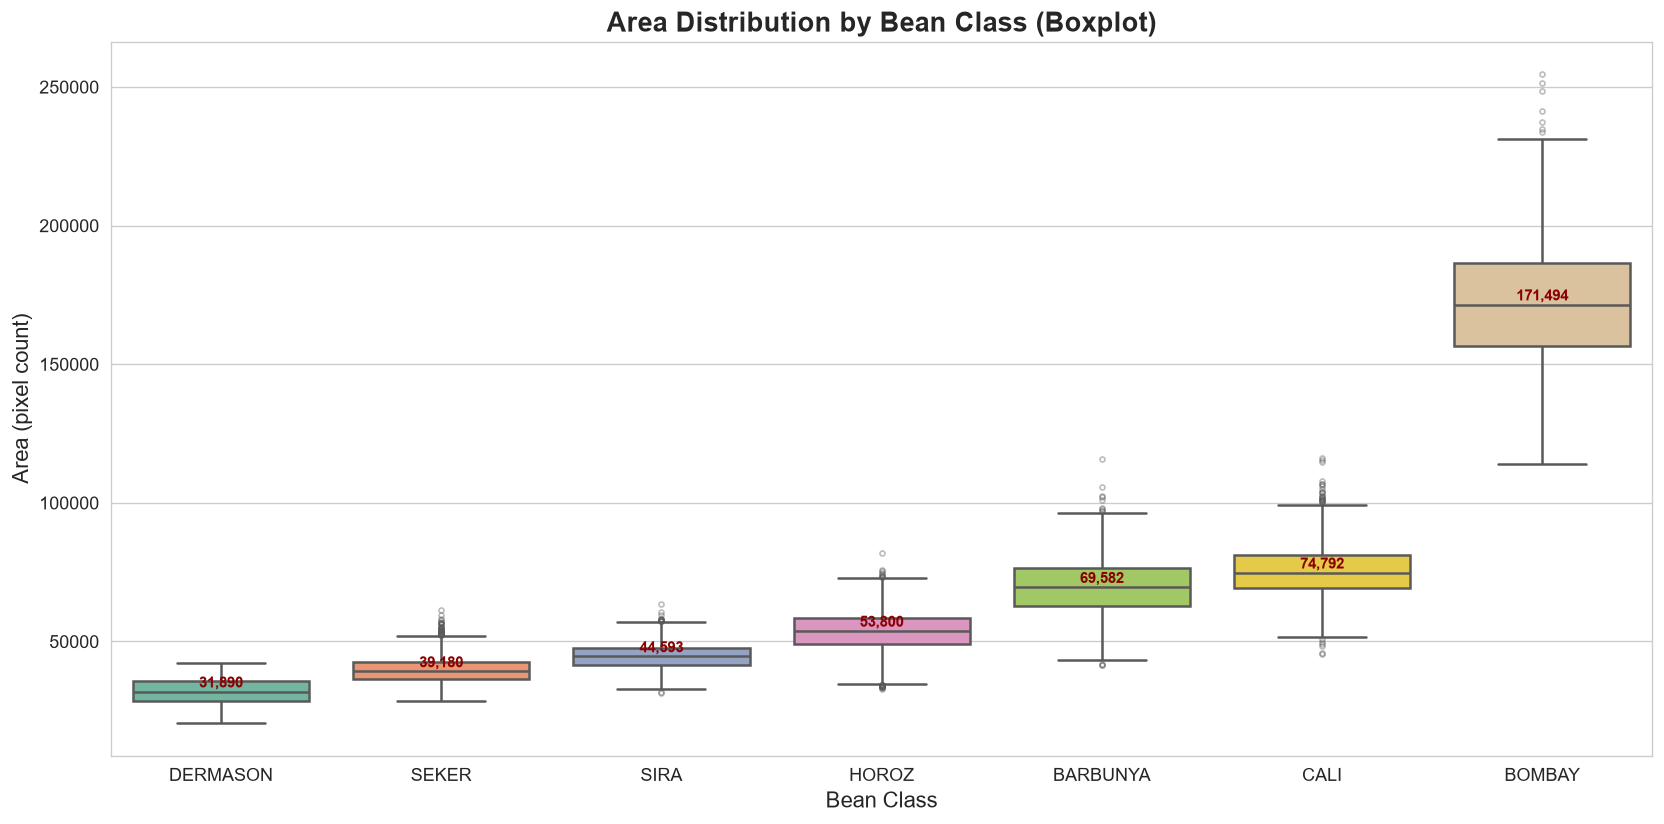

✅ Boxplot Area ذخیره شد.


In [24]:
# --- Visualization 2: Boxplot of Area by Class ---
fig, ax = plt.subplots(figsize=(14, 7))

class_order = df.groupby('Class')['Area'].median().sort_values().index
colors = sns.color_palette('Set2', n_colors=7)

bp = sns.boxplot(data=df, x='Class', y='Area', order=class_order, palette='Set2', ax=ax,
                 linewidth=1.5, fliersize=3, flierprops={'alpha': 0.4})

ax.set_title('Area Distribution by Bean Class (Boxplot)', fontsize=16, fontweight='bold')
ax.set_xlabel('Bean Class', fontsize=13)
ax.set_ylabel('Area (pixel count)', fontsize=13)

# Add median annotations
medians = df.groupby('Class')['Area'].median().reindex(class_order)
for i, (cls, med) in enumerate(medians.items()):
    ax.text(i, med + 1500, f'{med:,.0f}', ha='center', fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'area_boxplot_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplot Area ذخیره شد.')

### تحلیل Boxplot Area به تفکیک Class

**تفاوت میانه‌ها:** تفاوت قابل‌توجهی بین میانه‌های Area در کلاس‌های مختلف وجود دارد:
- **BOMBAY** بسیار بزرگ‌تر از سایرین است (Area میانه حدود ۱۵۰,۰۰۰+ پیکسل).
- **CALI** و **HOROZ** اندازه‌های متوسط تا بزرگ دارند.
- **SEKER** و **DERMASON** کوچک‌ترین هستند.

**پراکندگی:** کلاس‌هایی مانند BARBUNYA پراکندگی بیشتری دارند (جعبه بزرگ‌تر)، یعنی تنوع اندازه در این نوع لوبیا بیشتر است.

**مقادیر پرت:** نقاط خارج از سبیلک‌ها (whiskers) در اکثر کلاس‌ها دیده می‌شوند. این‌ها نمونه‌های حاشیه‌ای هر کلاس هستند.

**جداسازی:** BOMBAY به وضوح از سایر کلاس‌ها جدا است و احتمالاً در مدل‌سازی به راحتی تشخیص داده می‌شود. اما SEKER و DERMASON همپوشانی زیادی دارند.

---

### ۱۲.۳ — Scatter Plot: Area vs Perimeter

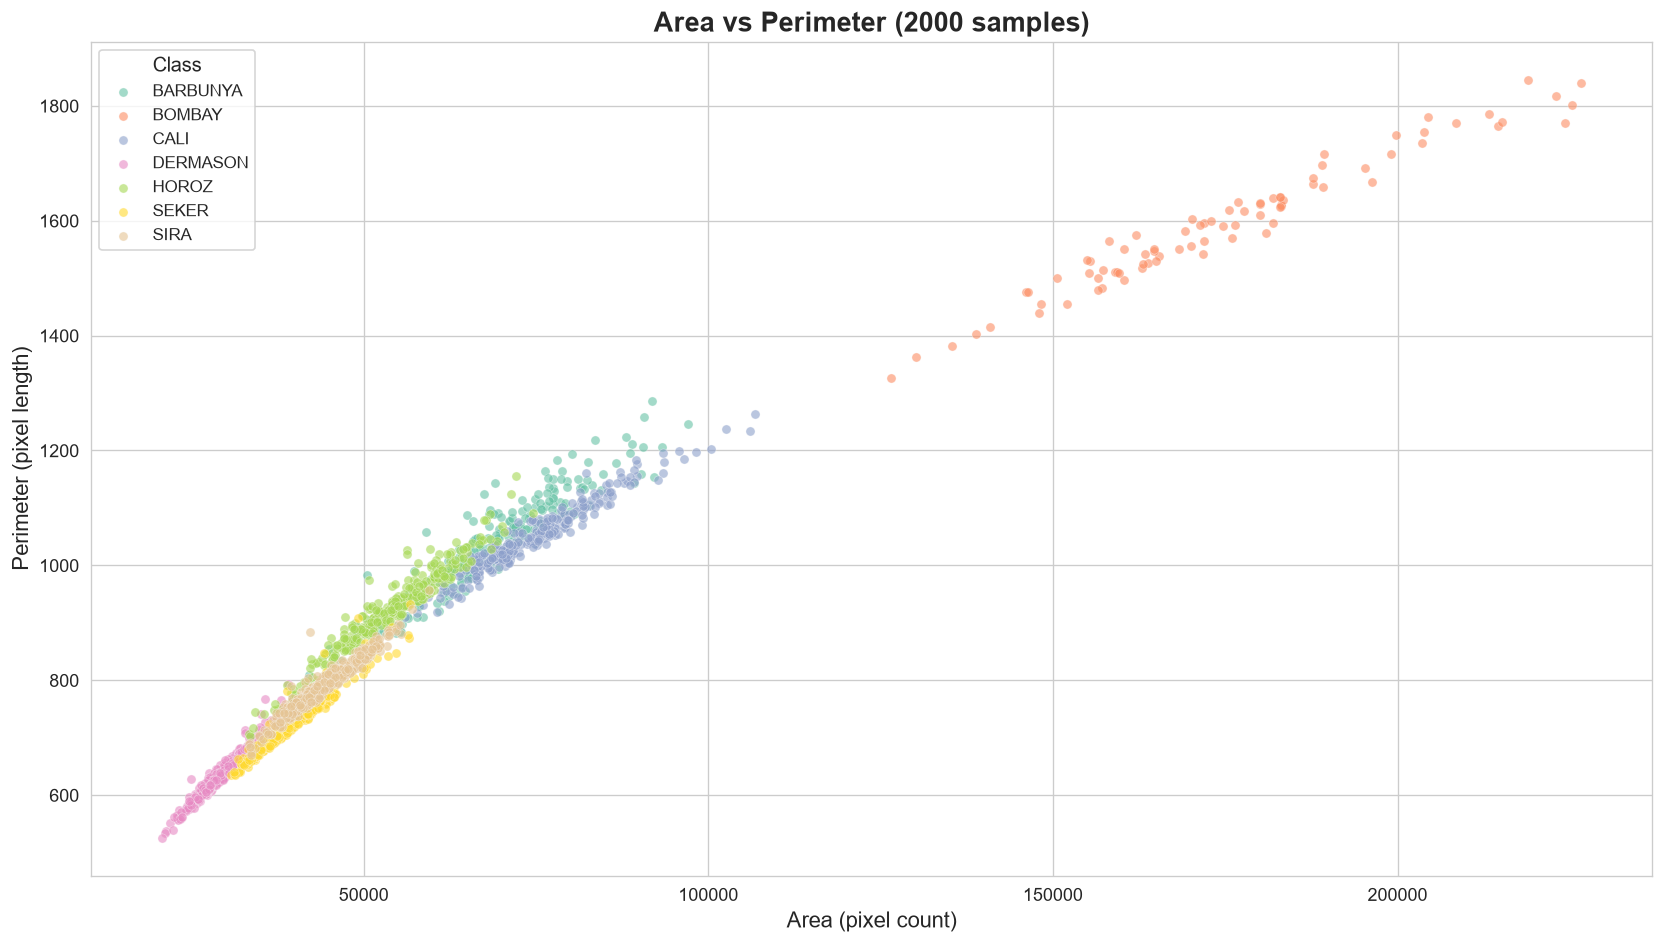

✅ Scatter Plot Area vs Perimeter ذخیره شد.


In [25]:
# --- Visualization 3: Scatter Plot - Area vs Perimeter ---
# Sample 2000 observations for visualization clarity
df_sample = df.sample(n=2000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 8))

classes = sorted(df['Class'].unique())
colors = sns.color_palette('Set2', n_colors=7)

for cls, color in zip(classes, colors):
    mask = df_sample['Class'] == cls
    ax.scatter(df_sample.loc[mask, 'Area'], df_sample.loc[mask, 'Perimeter'],
               c=[color], label=cls, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

ax.set_title('Area vs Perimeter (2000 samples)', fontsize=16, fontweight='bold')
ax.set_xlabel('Area (pixel count)', fontsize=13)
ax.set_ylabel('Perimeter (pixel length)', fontsize=13)
ax.legend(title='Class', fontsize=10, title_fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'area_perimeter_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter Plot Area vs Perimeter ذخیره شد.')

### تحلیل Scatter Plot: Area vs Perimeter

**چرا از ۲,۰۰۰ نمونه استفاده شد؟**
رسم ۱۳,۶۱۱ نقطه روی یک نمودار باعث تراکم و ناخوانایی می‌شود. نمونه‌گیری با `random_state=42` تضمین می‌کند که نتیجه تکرارپذیر است. **توجه:** برای مدل‌سازی، از کل دیتاست استفاده می‌شود.

**رابطه Area و Perimeter:** یک رابطه **مثبت و قوی** بین Area و Perimeter وجود دارد. هرچه مساحت بیشتر باشد، محیط نیز بیشتر است. این منطقی است زیرا هر دو ویژگی ابعاد فیزیکی دانه لوبیا را اندازه‌گیری می‌کنند.

**جداسازی کلاس‌ها:** کلاس BOMBAY (نقاط با Area بالا) به وضوح از سایرین جدا است. کلاس‌های CALI، HOROZ و BARBUNYA در نواحی میانی تراکم دارند و SEKER، DERMASON و SIRA در نواحی کوچک‌تر.

**همپوشانی:** همپوشانی قابل‌توجهی بین SEKER, DERMASON و SIRA وجود دارد. این یعنی تنها با Area و Perimeter نمی‌توان این کلاس‌ها را به خوبی از هم تفکیک کرد.

**اهمیت:** همبستگی بالای Area و Perimeter نشان می‌دهد که این دو ویژگی **اطلاعات تقریباً مشابهی** ارائه می‌دهند. این نکته در بحث ابعاد و فاصله مهم است.

---

### ۱۲.۴ — Scatter Plot: Compactness vs Eccentricity

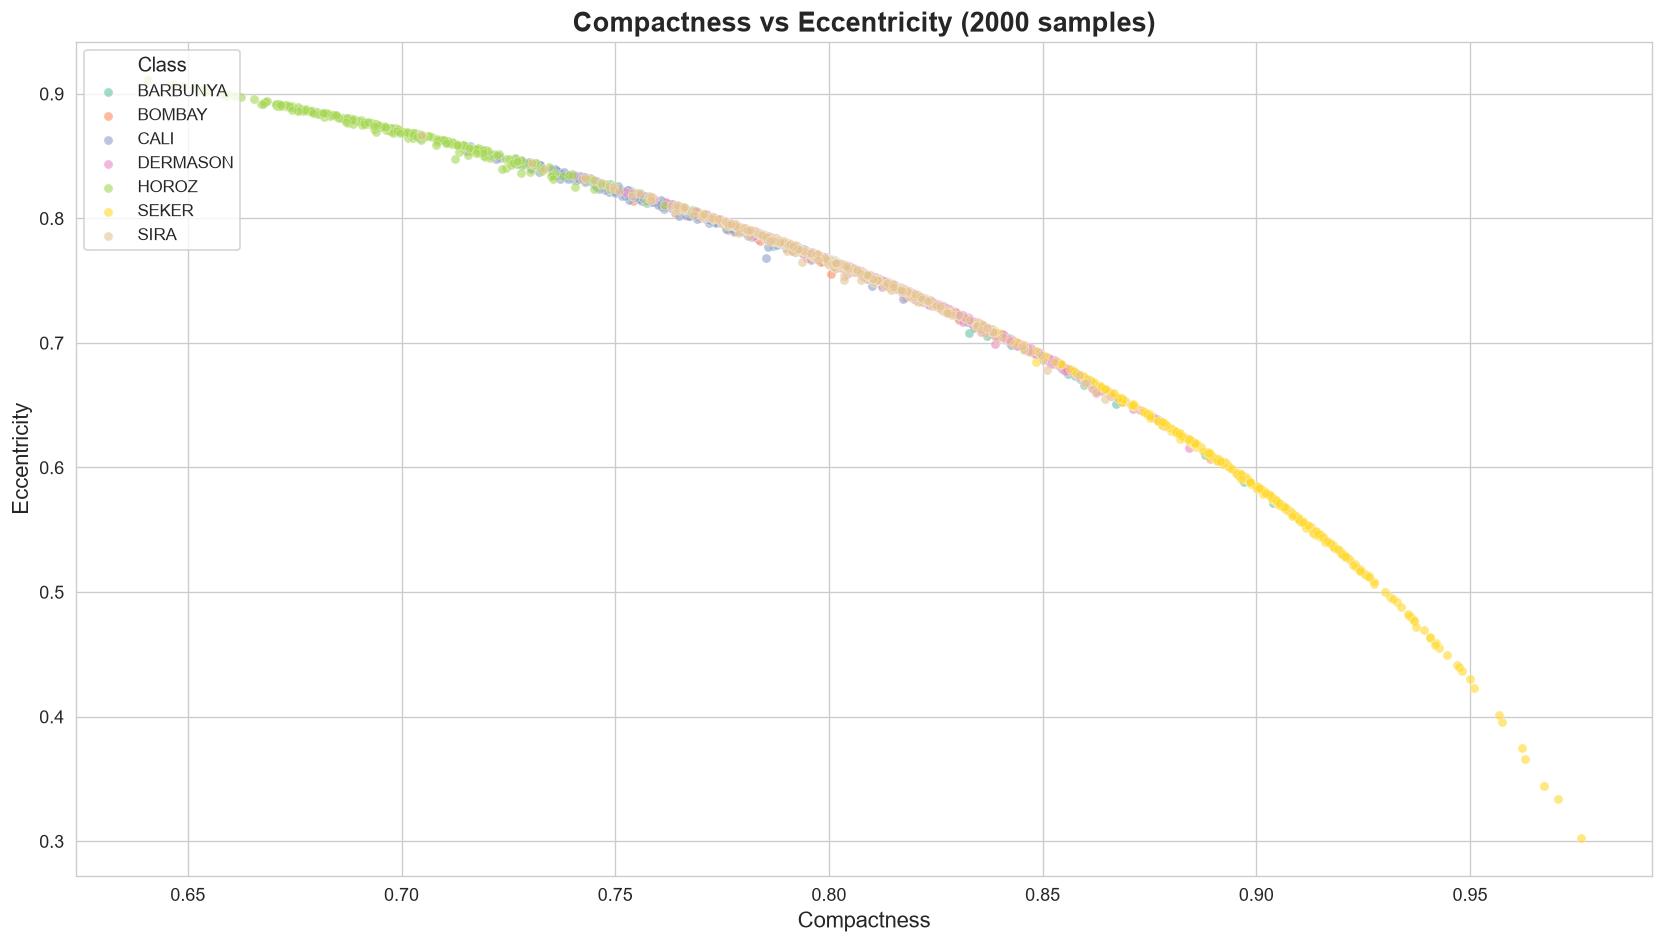

✅ Scatter Plot Compactness vs Eccentricity ذخیره شد.


In [26]:
# --- Visualization 4: Scatter Plot - Compactness vs Eccentricity ---
fig, ax = plt.subplots(figsize=(14, 8))

for cls, color in zip(classes, colors):
    mask = df_sample['Class'] == cls
    ax.scatter(df_sample.loc[mask, 'Compactness'], df_sample.loc[mask, 'Eccentricity'],
               c=[color], label=cls, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

ax.set_title('Compactness vs Eccentricity (2000 samples)', fontsize=16, fontweight='bold')
ax.set_xlabel('Compactness', fontsize=13)
ax.set_ylabel('Eccentricity', fontsize=13)
ax.legend(title='Class', fontsize=10, title_fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'compactness_eccentricity_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter Plot Compactness vs Eccentricity ذخیره شد.')

### تحلیل Scatter Plot: Compactness vs Eccentricity

**رابطه:** بین Compactness و Eccentricity یک **رابطه منفی قوی** وجود دارد. هرچه Compactness بیشتر (شکل‌ گردتر)، Eccentricity کمتر (کمتر بیضوی).

**جداسازی کلاس‌ها در فضای شکل:**
- **BOMBAY** (Compactness بالا، Eccentricity پایین): دانه‌های تقریباً گرد.
- **HOROZ** (Compactness پایین، Eccentricity بالا): دانه‌های کشیده.
- **SEKER** و **DERMASON:** در ناحیه Compactness بالا ولی با همپوشانی.
- **BARBUNYA**، **CALI** و **SIRA:** در نواحی میانی.

**همپوشانی:** برخلاف Area/Perimeter که عمدتاً اندازه را نشان می‌داد، Compactness/Eccentricity **شکل** را نشان می‌دهند. در این فضا، BOMBAY و HOROZ بهتر جدا هستند ولی DERMASON و SIRA همپوشانی زیادی دارند.

**اهمیت:** ترکیب ویژگی‌های اندازه (مانند Area) با ویژگی‌های شکل (مانند Compactness و Eccentricity) می‌تواند جداسازی بهتری ایجاد کند.

---

### ۱۲.۵ — ماتریس همبستگی (Correlation Matrix)

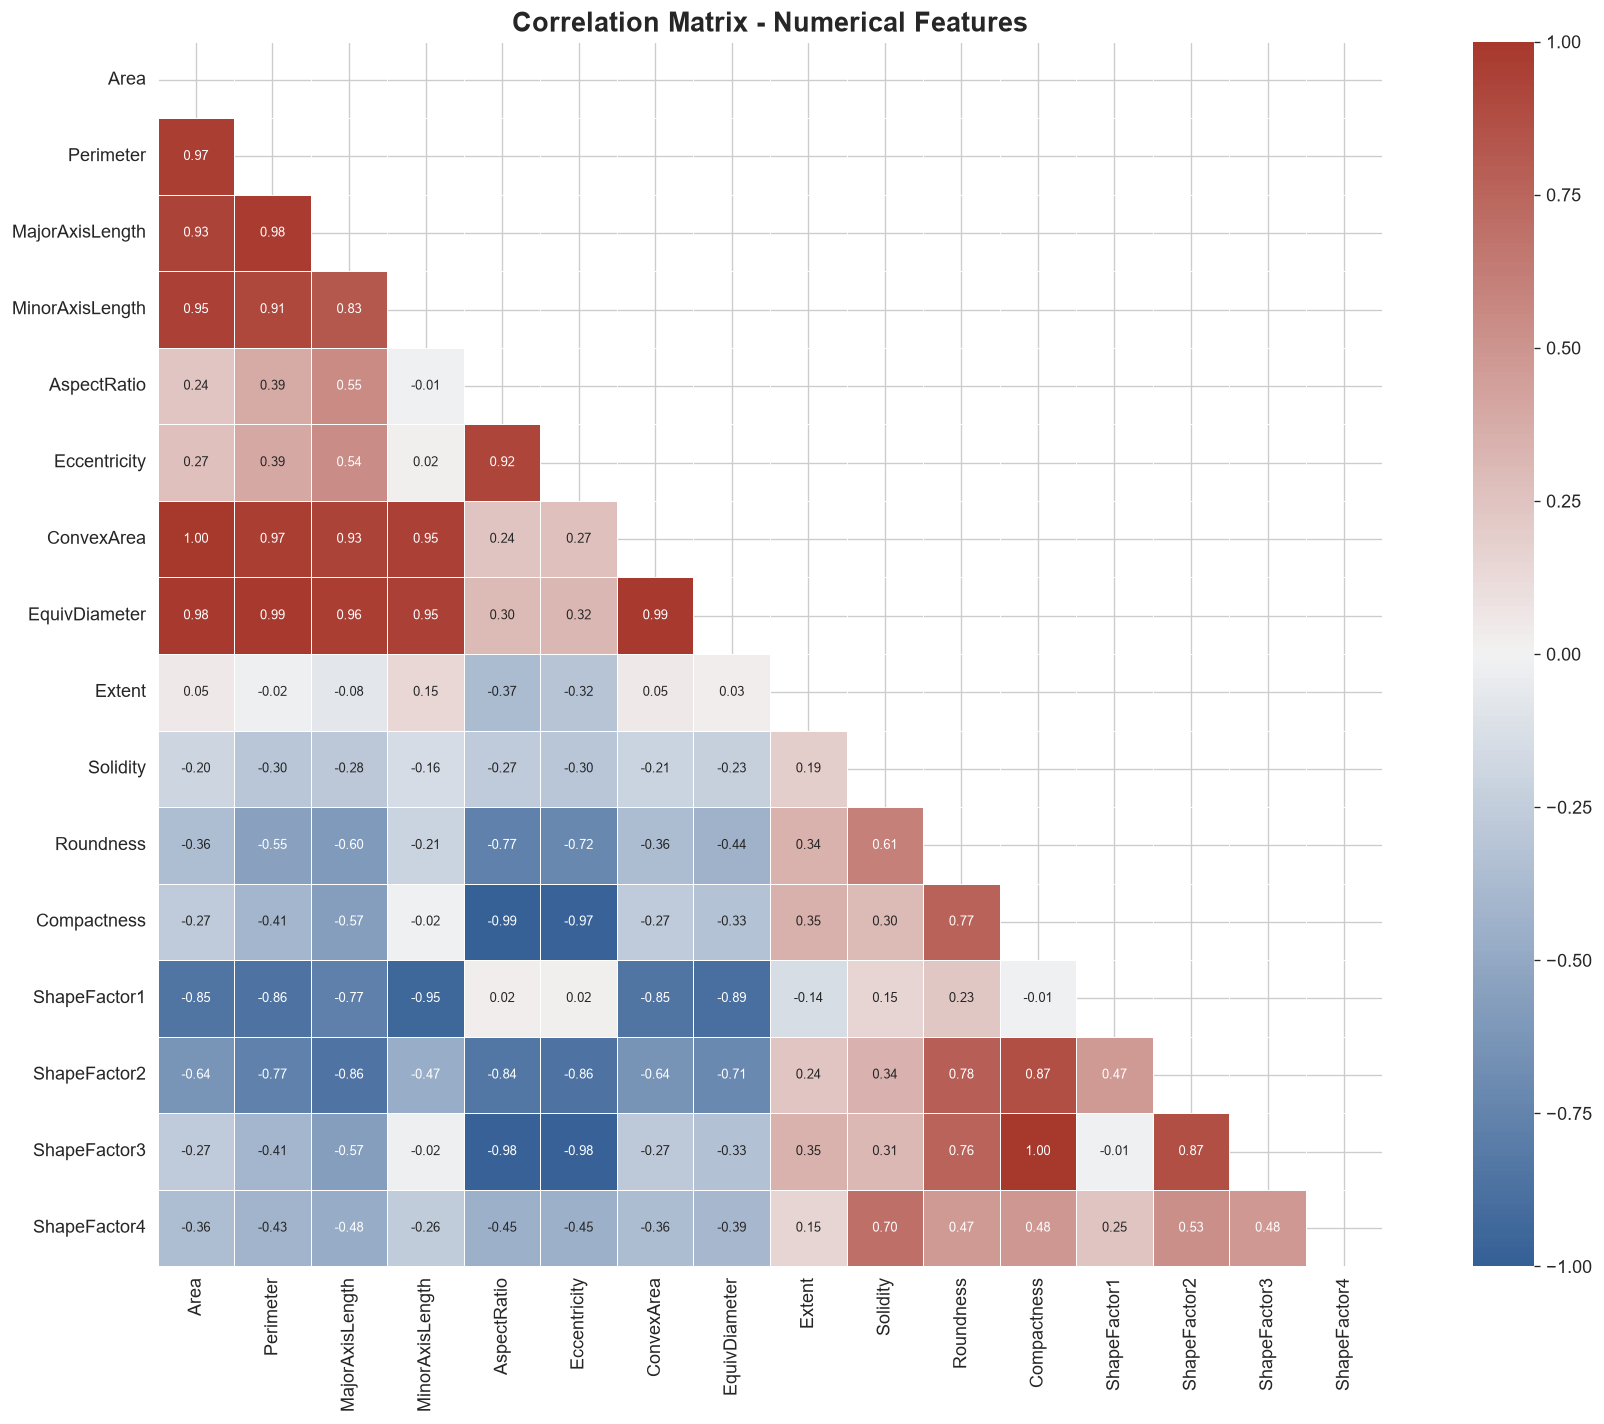

✅ ماتریس همبستگی ذخیره شد.


In [27]:
# --- Visualization 5: Correlation Matrix ---
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(16, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center='light', as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})

ax.set_title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ ماتریس همبستگی ذخیره شد.')

In [28]:
# --- Identify highly correlated pairs ---
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= 0.85:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(f'--- جفت ویژگی‌های با همبستگی بالا (|r| >= 0.85) ---')
print(f'تعداد: {len(high_corr_df)}')
display(high_corr_df)

--- جفت ویژگی‌های با همبستگی بالا (|r| >= 0.85) ---
تعداد: 27


,Feature 1,Feature 2,Correlation
3,Area,ConvexArea,0.9999
25,Compactness,ShapeFactor3,0.9987
8,Perimeter,EquivDiameter,0.9914
17,AspectRatio,Compactness,-0.9877
22,ConvexArea,EquivDiameter,0.9852
4,Area,EquivDiameter,0.9850
21,Eccentricity,ShapeFactor3,-0.9811
18,AspectRatio,ShapeFactor3,-0.9786
5,Perimeter,MajorAxisLength,0.9773
19,Eccentricity,Compactness,-0.9703


### تحلیل ماتریس همبستگی

**ویژگی‌های بسیار همبسته:**

1. **Area ↔ Perimeter ↔ ConvexArea ↔ EquivDiameter ↔ MajorAxisLength:** همبستگی بسیار بالا (۰.۸۵+). این منطقی است زیرا همه ابعاد فیزیکی یک دانه لوبیا را اندازه‌گیری می‌کنند. اگر دانه بزرگ‌تر باشد، همه این ویژگی‌ها بیشتر می‌شوند.

2. **AspectRatio ↔ Eccentricity ↔ Compactness ↔ Roundness ↔ ShapeFactor3:** همبستگی بالا. همه این‌ها شکل دانه را از زوایای مختلف اندازه‌گیری می‌کنند.

**آیا تمام ۱۶ ویژگی اطلاعات مستقل دارند؟**

**خیر.** چندین گروه از ویژگی‌ها اطلاعات مشابهی ارائه می‌دهند:
- گروه اندازه: Area, Perimeter, ConvexArea, EquivDiameter, MajorAxisLength
- گروه شکل: AspectRatio, Eccentricity, Compactness, Roundness, ShapeFactor3

**چرا این مهم است؟**

1. **برای KNN:** وجود ویژگی‌های همبسته به معنای شمارش مضاعف اطلاعات یکسان در محاسبه فاصله است. این می‌تواند به ویژگی‌های اندازه وزن بیشتری بدهد.

2. **برای K-Means:** مشابه KNN، ویژگی‌های همبسته می‌توانند خوشه‌بندی را به سمت یک بُعد خاص سوق دهند.

3. **Scale مشکل واحدها را حل می‌کند ولی مشکل ویژگی‌های تکراری را نه:** حتی بعد از StandardScaler، اگر ۵ ویژگی همگی اندازه را اندازه‌گیری کنند، اطلاعات اندازه ۵ بار در فاصله اقلیدسی شمرده می‌شود.

**نکته:** پروژه صراحتاً گفته PCA یا Feature Selection لازم نیست. فقط مسئله تحلیل شود.

---

## ۱۳. ذخیره دیتاست پردازش‌شده

In [29]:
# --- Save processed dataset ---
# Note: No rows were deleted (no missing, duplicates kept, outliers kept).
# The only change is column name correction.
df.to_csv(os.path.join(PROCESSED_DIR, 'dry_bean_clean.csv'), index=False, encoding='utf-8-sig')

print('✅ دیتاست پردازش‌شده ذخیره شد.')
print(f'   مسیر: {os.path.join(PROCESSED_DIR, "dry_bean_clean.csv")}')
print(f'   تعداد سطرها: {len(df):,}')
print(f'   تعداد ستون‌ها: {len(df.columns)}')
print(f'\nتغییرات نسبت به فایل خام:')
print(f'   ✓ اصلاح نام ستون AspectRation → AspectRatio')
print(f'   ✓ اصلاح نام ستون roundness → Roundness')
print(f'   ✗ هیچ سطری حذف نشده')
print(f'   ✗ هیچ مقداری تغییر نکرده')

✅ دیتاست پردازش‌شده ذخیره شد.
   مسیر: ..\data\processed\dry_bean_clean.csv
   تعداد سطرها: 13,611
   تعداد ستون‌ها: 17

تغییرات نسبت به فایل خام:
   ✓ اصلاح نام ستون AspectRation → AspectRatio
   ✓ اصلاح نام ستون roundness → Roundness
   ✗ هیچ سطری حذف نشده
   ✗ هیچ مقداری تغییر نکرده


---

## ۱۴. تحویل‌دهی به معمار (Analyst → Architect Handoff)

---

### وضعیت دیتاست

| مورد | مقدار |
|------|-------|
| تعداد سطرها | ۱۳,۶۱۱ |
| تعداد ویژگی‌ها | ۱۶ عددی |
| ستون هدف | Class (۷ کلاس) |
| مقادیر گمشده | ۰ |
| ردیف‌های تکراری | ۶۸ (حذف نشدند) |
| مقادیر غیرعددی | ۰ |
| مقادیر خارج از محدوده منطقی | ۰ |
| مقادیر غیرعادی آماری (IQR) | وجود دارند ولی حذف نشدند |

### مشخصات مدل‌سازی

برای مدل‌سازی، **X** شامل ۱۶ ویژگی عددی خواهد بود و **Class** به عنوان **y** استفاده می‌شود. تقسیم داده باید با `test_size=0.20`، `random_state=42` و `stratify=y` انجام شود.

**ستون Class تحت هیچ شرایطی نباید در ویژگی‌های مدل (X) قرار گیرد.**

### ⚠️ نکات مهم Scaling

- **StandardScaler باید فقط روی X_train آموزش ببیند** و سپس روی هر دو X_train و X_test اعمال شود.
- اگر StandardScaler روی کل دیتاست آموزش ببیند، اطلاعات از Test به Train نشت می‌کند (Data Leakage).

### یافته‌های مهم تحلیلی

1. دیتاست **نامتوازن** است: DERMASON ۶.۸ برابر BOMBAY.
2. Area, Perimeter, ConvexArea و EquivDiameter **همبستگی بسیار بالایی** دارند (>0.95).
3. BOMBAY متمایزترین کلاس است (اندازه بزرگ‌تر).
4. DERMASON و SIRA بیشترین همپوشانی را دارند.
5. مقیاس ویژگی‌ها بسیار متفاوت است: Area (۲۰K-۲۵۴K) vs Roundness (۰.۴۹-۰.۹۹).
6. مقادیر پرت آماری وجود دارند ولی حذف نشدند.
7. تمام مقادیر در محدوده منطقی قرار دارند (Range Validation = 0).

### هشدارها برای مدل‌سازی

- **عدم توازن کلاس‌ها:** Macro Recall و Macro F1 بهتر از Accuracy هستند.
- **ویژگی‌های همبسته:** ۱۶ ویژگی اطلاعات مستقل ندارند. این می‌تواند فاصله اقلیدسی را سوق‌دار کند.
- **مقادیر پرت:** KNN و K-Means به آن‌ها حساس هستند.
- **تفاوت مقیاس:** Scale ضروری است. بدون آن، Area به تنهایی فاصله را تسلط می‌یابد.
- **K-Means:** شماره Cluster ≠ شماره Class. نگاشت لازم است.

> **توجه:** اجرای عملی Train/Test Split و Scaling در نوت‌بوک مدل‌سازی (Architect) انجام خواهد شد. این بخش صرفاً مشخصات لازم را مستند می‌کند.

---

---

### پایان نوت‌بوک تحلیلگر

تمام موارد زیر انجام شد:

- ✅ بارگذاری و شناخت داده
- ✅ بررسی ابعاد دیتاست
- ✅ نمایش سطرهای اول و آخر
- ✅ بررسی نوع داده‌ها
- ✅ یکسان‌سازی نام ستون‌ها
- ✅ بررسی مقادیر گمشده
- ✅ بررسی ردیف‌های تکراری
- ✅ بررسی مقادیر غیرعددی
- ✅ توزیع کلاس‌ها
- ✅ تحلیل مقادیر غیرعادی (IQR)
- ✅ بررسی محدوده منطقی (Range Validation)
- ✅ فرهنگ داده (Data Dictionary)
- ✅ آمار توصیفی
- ✅ تحلیل تصویری (۵ نمودار)
- ✅ ماتریس همبستگی
- ✅ تحویل‌دهی به معمار (مشخصات — بدون اجرا)

**فایل‌های تولید شده:**
- `data/processed/dry_bean_clean.csv`
- `data/processed/descriptive_statistics.csv`
- `docs/data_dictionary.csv`
- `figures/class_distribution.png`
- `figures/area_histogram.png`
- `figures/area_boxplot_by_class.png`
- `figures/area_perimeter_scatter.png`
- `figures/compactness_eccentricity_scatter.png`
- `figures/correlation_matrix.png`